In [9]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [10]:
# 1. Загрузка данных
# Предполагаем, что есть CSV с колонками: datetime, open, high, low, close, volume
# df = pd.read_csv('dowload_data/CNYRUBF_1Min.txt', parse_dates=['datetime'], index_col='datetime')
def readQuotes(path):
    try:
        quotes = pd.read_csv(path, sep=';')
        quotes['date'] = quotes['date'] + ' ' + quotes['time']
        del quotes['time']
        quotes['date'] = pd.to_datetime(quotes['date'], format='%d.%m.%Y %H:%M:%S', errors='raise', dayfirst=True)
        quotes.index = quotes['date']
        quotes.index.name = 'Date'
        del quotes['date']
        quotes[quotes.columns].astype(float)
        return quotes
    except pd.errors.EmptyDataError:
        print(f"File {path} is empty")
        return pd.DataFrame()
    except pd.errors.ParserError as e:
        print(f"Error parsing file {path}: {e}")

In [1]:
df_base = readQuotes('..\dowload_data\CNYRUBF_5Min.txt')
df_history = readQuotes('..\dowload_data\CNYRUBF_5Min_history.txt')

data_inp = pd.concat([df_history, df_base])

NameError: name 'readQuotes' is not defined

In [12]:
data = data_inp.loc[:'2025-04-29 10:00:00',:].copy()

# Начинается модель

In [ ]:
from statsmodels.tsa.stattools import adfuller

p-value: 0.7483294722467894


In [ ]:
def test_stationarity(series, title=''):
    print(f"Results of ADF Test on {title}:")
    result = adfuller(series, autolag='AIC')
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    if result[1] > 0.05:
        print("Non-stationary")
    else:
        print("stationary")
    for key, value in result[4].items():
        print(f"Critical Value ({key}): {value}")
    print("\n")

test_stationarity(series, 'Counts')

Results of ADF Test on Counts:
ADF Statistic: -1.0134437605700561
p-value: 0.7483294722467894
Non-stationary
Critical Value (1%): -3.4304663940337843
Critical Value (5%): -2.861591443897319
Critical Value (10%): -2.5667973818634073




In [256]:
test_stationarity(diff, 'Counts')

Results of ADF Test on Counts:
ADF Statistic: -29.81049707136434
p-value: 0.0
stationary
Critical Value (1%): -3.430466396105537
Critical Value (5%): -2.8615914448129756
Critical Value (10%): -2.5667973823507837




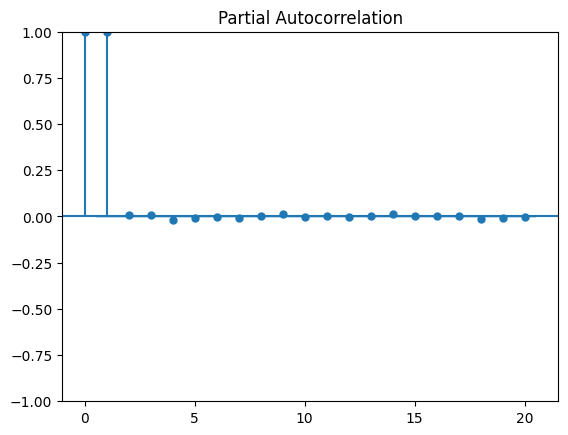

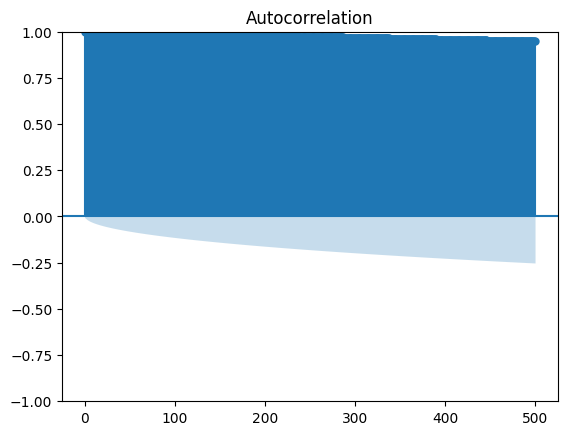

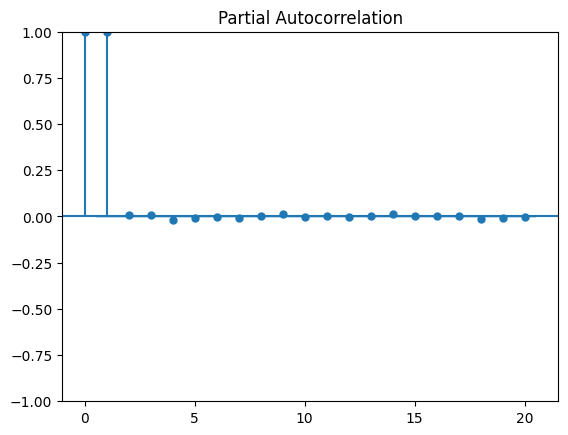

In [358]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(series, lags=500)  # Для q (обрезка после лага)
plot_pacf(series, lags=20) # Для p (обрезка после лага)

In [356]:
series = data['close'].dropna()

In [13]:
# Разделение данных - последние 6 свечей для теста
train_size = int(len(series) - 6)
train, test = series[0:train_size], series[train_size:len(series)]

In [ ]:
# Функция для оценки модели ARIMA
def evaluate_arima_model(X, arima_order):
    # Подготовка данных
    X = X.values
    train, test = X[0:-6], X[-6:]
    history = [x for x in train]
    # Создание прогнозов
    predictions = list()
    for t in range(len(test)):
        model = ARIMA(history, order=arima_order)
        model_fit = model.fit()
        yhat = model_fit.forecast(steps=1)[0]
        predictions.append(yhat)
        history.append(test[t])
    # Расчет ошибки
    error = mean_squared_error(test, predictions)
    return error, predictions

# Поиск лучших параметров p,d,q (может занять много времени)
def evaluate_models(dataset, p_values, d_values, q_values):
    best_score, best_cfg = float("inf"), None
    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p,d,q)
                try:
                    mse, _ = evaluate_arima_model(dataset, order)
                    if mse < best_score:
                        best_score, best_cfg = mse, order
                    print('ARIMA%s MSE=%.5f' % (order,mse))
                except:
                    continue
    print('Лучшая ARIMA%s MSE=%.5f' % (best_cfg, best_score))
    return best_cfg

# Поиск параметров (это может занять много времени)
p_values = [0, 1, 2, 4]
d_values = [0, 1]
q_values = [0, 1, 2]
best_order = evaluate_models(series, p_values, d_values, q_values)

ARIMA(0, 0, 0) MSE=1.916
ARIMA(0, 0, 1) MSE=0.486
ARIMA(0, 0, 2) MSE=0.137


c:\QUIK_VTB\scripts\my_venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\QUIK_VTB\scripts\my_venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\QUIK_VTB\scripts\my_venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\QUIK_VTB\scripts\my_venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(0, 1, 0) MSE=0.000
ARIMA(0, 1, 1) MSE=0.000
ARIMA(0, 1, 2) MSE=0.000
ARIMA(1, 0, 0) MSE=0.000
ARIMA(1, 0, 1) MSE=0.000
ARIMA(1, 0, 2) MSE=0.000


c:\QUIK_VTB\scripts\my_venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(1, 1, 0) MSE=0.000


...

ARIMA(4, 0, 2) MSE=0.000
ARIMA(4, 1, 0) MSE=0.000


c:\QUIK_VTB\scripts\my_venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\QUIK_VTB\scripts\my_venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\QUIK_VTB\scripts\my_venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(4, 1, 1) MSE=0.000


c:\QUIK_VTB\scripts\my_venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\QUIK_VTB\scripts\my_venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(4, 1, 2) MSE=0.000
Лучшая ARIMA(2, 0, 1) MSE=0.000


In [6]:
import tensorflow as tf

In [2]:
print("TensorFlow version:", tf.version.VERSION)
print("GPU доступен:", "Да" if tf.config.list_physical_devices('GPU') else "Нет")

TensorFlow version: 2.16.1
GPU доступен: Нет


In [5]:
tf.config.set_visible_devices([], 'GPU')  # Сбросить настройки
tf.debugging.set_log_device_placement(True)  # Показать, где выполняются операции

In [8]:
tf.config.list_physical_devices('GPU')

[]

In [7]:
# Проверка поддержки CUDA
print("Поддержка CUDA:", tf.test.is_built_with_cuda())

Поддержка CUDA: False


c:\QUIK_VTB\scripts\my_venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\QUIK_VTB\scripts\my_venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\QUIK_VTB\scripts\my_venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\QUIK_VTB\scripts\my_venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.

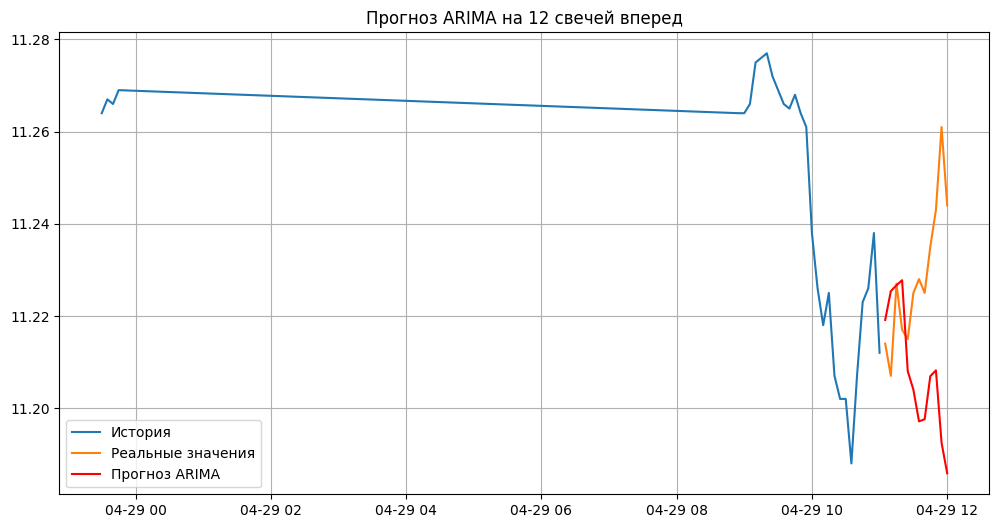

MSE: 0.0010622833953040861


In [361]:
future_candles = 12
# Обучение модели с лучшими параметрами
train = data_inp.loc[:'2025-04-29 11:00:00',:]['close'][-30:]
test = data_inp.loc['2025-04-29 11:05:00':,:]['close'][:future_candles]

# ARIMA(p, d, q)
model = ARIMA(train, order=(50,1,50))#best_order)
model_fit = model.fit()

# Прогноз на 6 шагов вперед
forecast = model_fit.forecast(steps=future_candles)

# Визуализация
plt.figure(figsize=(12,6))
plt.plot(train.index[-50:], train.values[-50:], label='История')
plt.plot(test.index, test.values, label='Реальные значения')
plt.plot(test.index, forecast, label='Прогноз ARIMA', color='red')
plt.legend()
plt.title(f'Прогноз ARIMA на {future_candles} свечей вперед')
plt.grid(True)
plt.show()

# Оценка точности
mse = mean_squared_error(test, forecast)
print(f'MSE: {mse}')

In [219]:
from prophet import Prophet

series_ =  data_inp.loc[:'2025-04-29 17:00:00',:][-100:]
series_['index'] = series_.index

# Подготовка данных для Prophet
prophet_df = series_.reset_index()[['index', 'close']].rename(columns={'index': 'ds', 'close': 'y'})

# Очистка выбросов
prophet_df['y'] = np.log(prophet_df['y'])  # Логарифмируем
q = prophet_df['y'].quantile(0.70)
prophet_df.loc[prophet_df['y'] > q, 'y'] = q  # Обрезаем выбросы

# Создание и обучение модели
model = Prophet(
    changepoint_prior_scale=0.1,
    seasonality_mode='multiplicative',  # Для финансовых данных часто лучше
    daily_seasonality=True,  # Включаем дневные паттерны
    weekly_seasonality=True, # Недельные циклы
    yearly_seasonality=False # Для внутридневных данных обычно не нужно
)
# Добавляем кастомную сезонность (например, внутридневные паттерны)
# model.add_seasonality(name='hourly', period=1/24, fourier_order=5)  # Часовые колебания

model.fit(prophet_df)

# Прогноз на 6 свечей (30 минут)
future = model.make_future_dataframe(periods=4, freq='5min')
forecast = model.predict(future)

10:49:29 - cmdstanpy - INFO - Chain [1] start processing
10:49:29 - cmdstanpy - INFO - Chain [1] done processing


In [220]:
forecast['yhat'] = np.exp(forecast['yhat'])

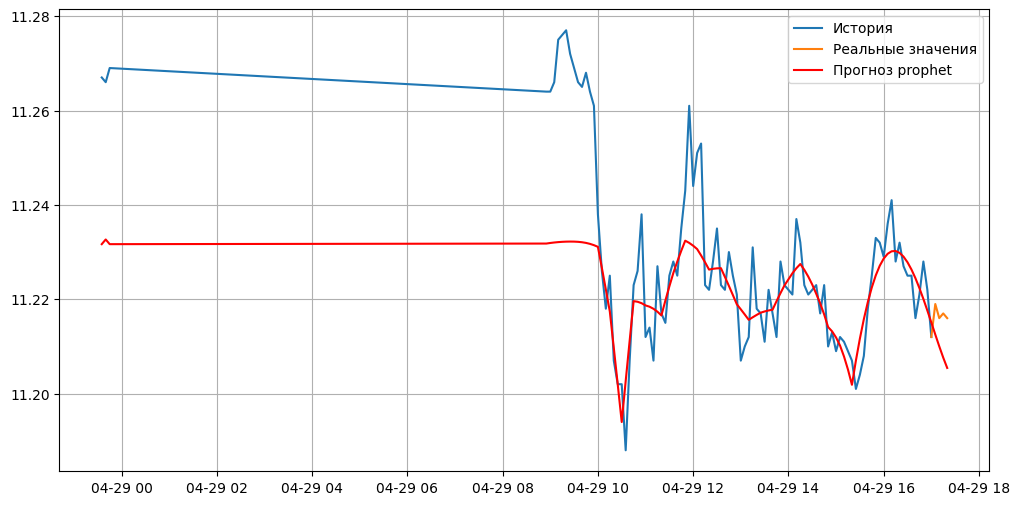

In [221]:
test = data_inp.loc['2025-04-29 17:00:00':,:][:5]
plt.figure(figsize=(12,6))
plt.plot(prophet_df['ds'], series_['close'], label='История')
plt.plot(test.index, test['close'], label='Реальные значения')
plt.plot(forecast.ds, forecast.yhat, label='Прогноз prophet', color='red')
# plt.plot(forecast.ds, forecast.yhat_lower, label='Прогноз prophet', color='green')
# plt.plot(forecast.ds, forecast.yhat_upper, label='Прогноз prophet', color='green')
plt.legend()
# plt.title('Прогноз ARIMA на 6 свечей вперед')
plt.grid(True)
plt.show()